# Traffic Sign Recognition — GTSRB


## Import Libraries

In [1]:
import os, gc, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-03-03 00:28:41.814310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772497722.017849      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772497722.079434      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772497722.589499      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772497722.589570      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772497722.589573      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 64
EPOCHS      = 30
NUM_CLASSES = 43

DATASET_NAME = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign' 
DATA_DIR  = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
TRAIN_DIR = f'{DATA_DIR}/Train'
TEST_CSV  = f'{DATA_DIR}/Test.csv'

print('Data dir exists: ', os.path.exists(DATA_DIR))
print('Train dir exists:', os.path.exists(TRAIN_DIR))
print('Test CSV exists: ', os.path.exists(TEST_CSV))
print('Classes found:   ', len([f for f in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, f))]))

Data dir exists:  True
Train dir exists: True
Test CSV exists:  True
Classes found:    43


## Load & Preprocess Training Images

In [3]:
images, labels = [], []

for class_folder in sorted(os.listdir(TRAIN_DIR)):
    class_path = os.path.join(TRAIN_DIR, class_folder)
    if not os.path.isdir(class_path):
        continue
    for file in os.listdir(class_path):
        img = cv2.imread(os.path.join(class_path, file))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        images.append(img)
        labels.append(int(class_folder))

X = np.array(images, dtype='float32') / 255.0
y = np.array(labels, dtype='int32')

del images, labels
gc.collect()

y_cat = to_categorical(y, NUM_CLASSES)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=42)

del X
gc.collect()

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Shape: {X_train.shape[1:]}')

Train: 31367 | Val: 7842 | Shape: (64, 64, 3)


## Check

In [4]:
print('X_train shape:  ', X_train.shape)   # (N, 64, 64, 3)
print('y_train shape:  ', y_train.shape)   # (N, 43)
print('Max pixel value:', X_train.max())   # ~1.0
print('Unique classes: ', len(np.unique(np.argmax(y_train, axis=1))))  # 43

X_train shape:   (31367, 64, 64, 3)
y_train shape:   (31367, 43)
Max pixel value: 1.0
Unique classes:  43


## Explore the Data

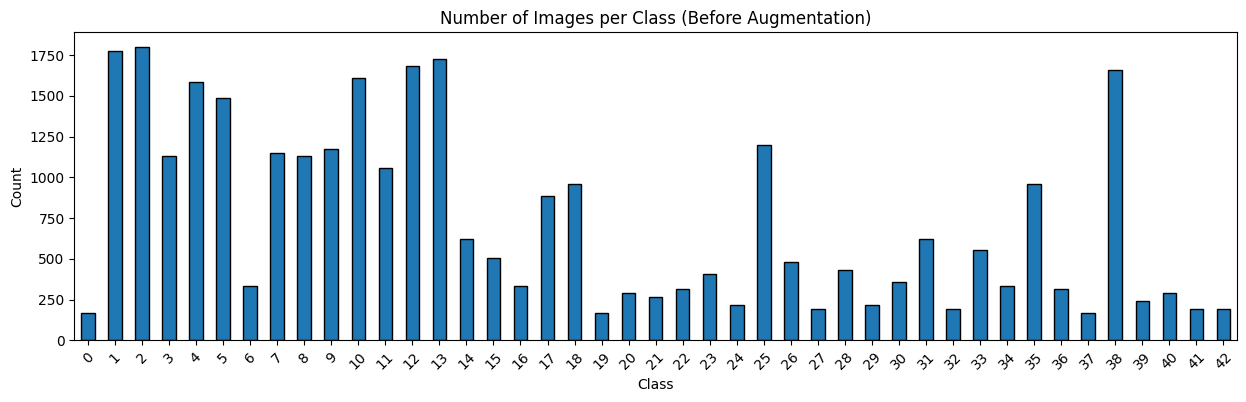

Min samples: 168 | Max samples: 1800


In [5]:
counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()

plt.figure(figsize=(15, 4))
counts.plot(kind='bar', edgecolor='black')
plt.title('Number of Images per Class (Before Augmentation)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(f'Min samples: {counts.min()} | Max samples: {counts.max()}')

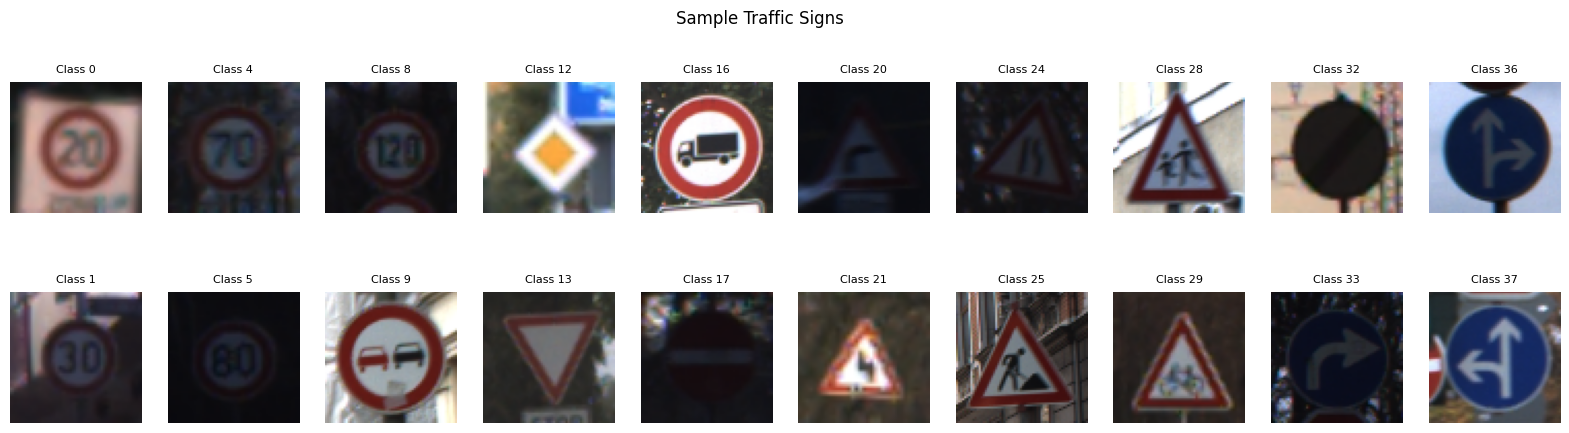

In [6]:

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i in range(10):
    for row, offset in enumerate([0, 1]):
        class_id = i * 4 + offset
        idx = np.where(np.argmax(y_train, axis=1) == class_id)[0][0]
        axes[row, i].imshow(X_train[idx])
        axes[row, i].set_title(f'Class {class_id}', fontsize=8)
        axes[row, i].axis('off')
plt.suptitle('Sample Traffic Signs')
plt.show()

## Data Augmentation 

In [7]:
train_datagen = ImageDataGenerator(
    rotation_range=15,        
    width_shift_range=0.1,   
    height_shift_range=0.1,   
    zoom_range=0.1,          
    brightness_range=[0.8, 1.2], 
    horizontal_flip=False    )
val_datagen = ImageDataGenerator() 

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

## Build Custom CNN

In [8]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(43, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772497932.523210      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772497932.529184      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,248,779 (8.58 MB)

 Trainable params: 2,248,331 (8.58 MB)

 Non-trainable params: 448 (1.75 KB)

## Train Custom CNN

In [9]:
class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(np.argmax(y_train, axis=1)),y=np.argmax(y_train, axis=1))
class_weight_dict = dict(enumerate(class_weights))

callbacks = [EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
             ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)]

cnn_history = cnn_model.fit(X_train, y_train,batch_size=BATCH_SIZE,epochs=EPOCHS,validation_data=(X_val, y_val),class_weight=class_weight_dict,callbacks=callbacks)

Epoch 1/30


I0000 00:00:1772497940.344804     129 service.cc:152] XLA service 0x7a63a000bf00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772497940.344863     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772497940.344870     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772497941.019087     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-03 00:32:23.689572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:32:23.834676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  5/491 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.0195 - loss: 8.3057 

I0000 00:00:1772497949.237748     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


489/491 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0369 - loss: 4.0786

2026-03-03 00:32:40.772222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:32:40.910602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


491/491 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.0370 - loss: 4.0760 - val_accuracy: 0.1707 - val_loss: 3.5832 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.1465 - loss: 3.0249 - val_accuracy: 0.3268 - val_loss: 2.1121 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.2618 - loss: 2.4795 - val_accuracy: 0.4723 - val_loss: 1.6087 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.3560 - loss: 1.9882 - val_accuracy: 0.6357 - val_loss: 1.1332 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.5405 - loss: 1.3325 - val_accuracy: 0.8910 - val_loss: 0.3361 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7634 - loss: 0.6532 - val_accuracy: 0.9373 - val_loss: 0.1848 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8671 - loss: 0.4013

## Build & Train MobileNetV2

In [10]:
import os
for root, dirs, files in os.walk('/kaggle/input/mobilenetv2-weights'):
    for file in files:
        print(os.path.join(root, file))


In [11]:
import gc
gc.collect()
tf.keras.backend.clear_session()
X_train_mob = tf.image.resize(X_train, (96,96)).numpy()
X_val_mob   = tf.image.resize(X_val,   (96,96)).numpy()

base = MobileNetV2(weights=None, include_top=False, input_shape=(96,96,3))
base.trainable = True 

mob_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(43, activation='softmax')])

mob_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss='categorical_crossentropy',metrics=['accuracy'])

mob_h1 = mob_model.fit( X_train_mob, y_train, batch_size=BATCH_SIZE,epochs=EPOCHS, validation_data=(X_val_mob, y_val), callbacks=callbacks)
del X_train_mob, X_val_mob
gc.collect()

Epoch 1/30


2026-03-03 00:39:13.984877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:39:14.120558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:39:14.256862: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2101 - loss: 2.8808

2026-03-03 00:40:06.753249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:40:06.907951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:40:07.043369: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:40:10.206045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:40:10.338967: E external/local_xla/xla/stream_

491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2104 - loss: 2.8793

2026-03-03 00:40:38.231962: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 00:40:38.376363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


491/491 ━━━━━━━━━━━━━━━━━━━━ 121s 139ms/step - accuracy: 0.2107 - loss: 2.8778 - val_accuracy: 0.0360 - val_loss: 3.8050 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.7573 - loss: 0.7690 - val_accuracy: 0.0474 - val_loss: 5.7983 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.8864 - loss: 0.3807 - val_accuracy: 0.0474 - val_loss: 6.0850 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9490 - loss: 0.1861 - val_accuracy: 0.0474 - val_loss: 5.5629 - learning_rate: 0.0010
Epoch 5/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9543 - loss: 0.1622
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.9544 - loss: 0.1621 - val_accuracy: 0.0474 - val_loss: 4.9157 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.9815 - loss: 0.0759

9208

## Plot Training Curves

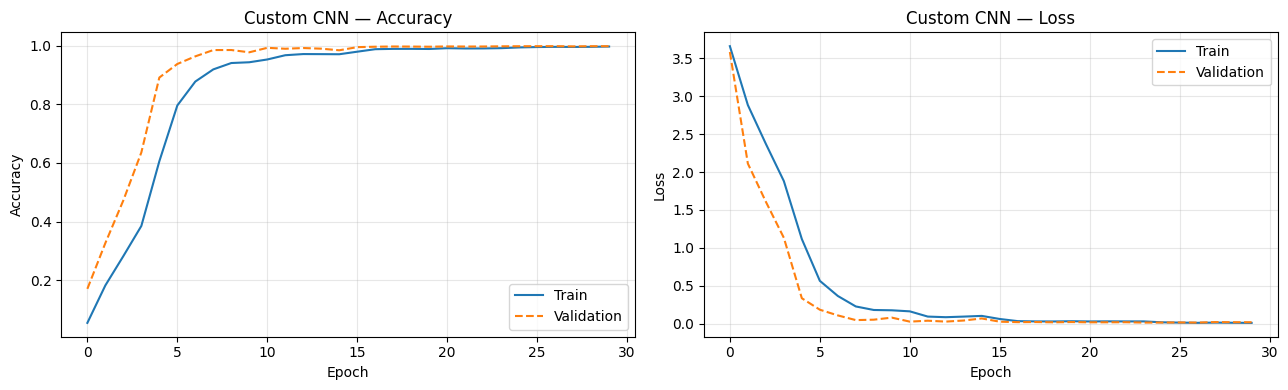

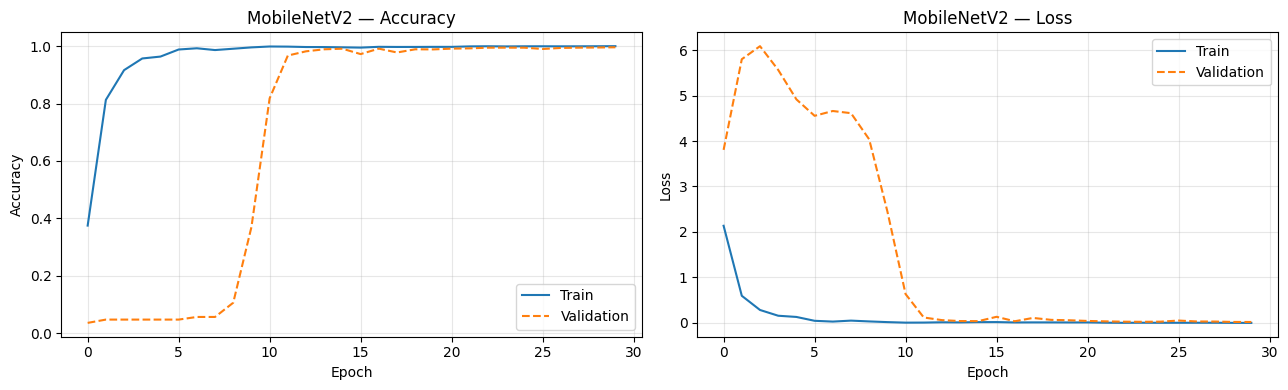

In [20]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation', linestyle='--')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validation', linestyle='--')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(cnn_history, 'Custom CNN')
plot_history(mob_h1, 'MobileNetV2')

## Load Test Data

In [16]:
df_test = pd.read_csv(TEST_CSV)
print('Columns:', df_test.columns.tolist())

X_test, y_test = [], []
for _, row in df_test.iterrows():
    img_path = os.path.join(DATA_DIR, row['Path']) if 'Path' in df_test.columns \
               else os.path.join(DATA_DIR, 'Test', row['Filename'])
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    X_test.append(img)
    y_test.append(row['ClassId'])

X_test = np.array(X_test, dtype='float32') / 255.0
y_test = np.array(y_test)
print(f'Test images loaded: {len(X_test)}')

Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Test images loaded: 12630


## Evaluate Both Models

Custom CNN   — Accuracy: 97.51%  |  Loss: 0.1707
MobileNetV2  — Accuracy: 97.21%  |  Loss: 0.1660


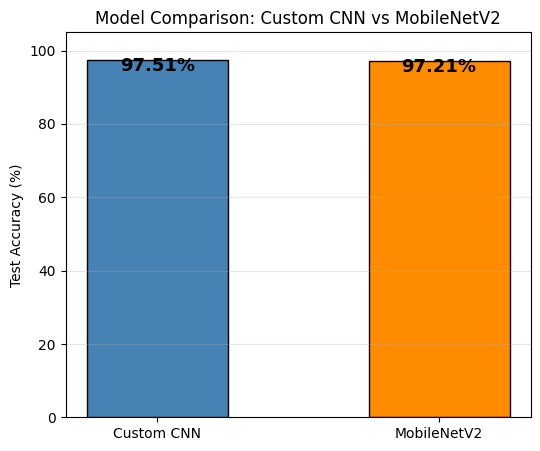

In [18]:
y_test_cat  = to_categorical(y_test, NUM_CLASSES)
X_test_mob  = tf.image.resize(X_test, (96,96)).numpy()

cnn_loss, cnn_acc = cnn_model.evaluate(X_test,     y_test_cat, verbose=0)
mob_loss, mob_acc = mob_model.evaluate(X_test_mob, y_test_cat, verbose=0)

print(f'Custom CNN   — Accuracy: {cnn_acc*100:.2f}%  |  Loss: {cnn_loss:.4f}')
print(f'MobileNetV2  — Accuracy: {mob_acc*100:.2f}%  |  Loss: {mob_loss:.4f}')

plt.figure(figsize=(6, 5))
bars = plt.bar(['Custom CNN', 'MobileNetV2'], [cnn_acc*100, mob_acc*100],
               color=['steelblue', 'darkorange'], edgecolor='black', width=0.5)
for bar, acc in zip(bars, [cnn_acc, mob_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f'{acc*100:.2f}%', ha='center', color='black', fontweight='bold', fontsize=13)
plt.ylim(0, 105)
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison: Custom CNN vs MobileNetV2')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Confusion Matrix & Classification Report


Custom CNN — Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       0.96      0.99      0.97       720
           2       0.99      0.98      0.98       750
           3       0.97      0.93      0.95       450
           4       1.00      0.99      0.99       660
           5       0.94      0.99      0.97       630
           6       1.00      0.91      0.95       150
           7       0.97      0.98      0.97       450
           8       0.99      0.98      0.98       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       0.97      1.00      0.98       420
          12       0.99      0.96      0.97       690
          13       0.97      1.00      0.99       720
          14       1.00      1.00      1.00       270
          15       0.93      1.00      0.96       210
          16       1.00      1.00      1.00 

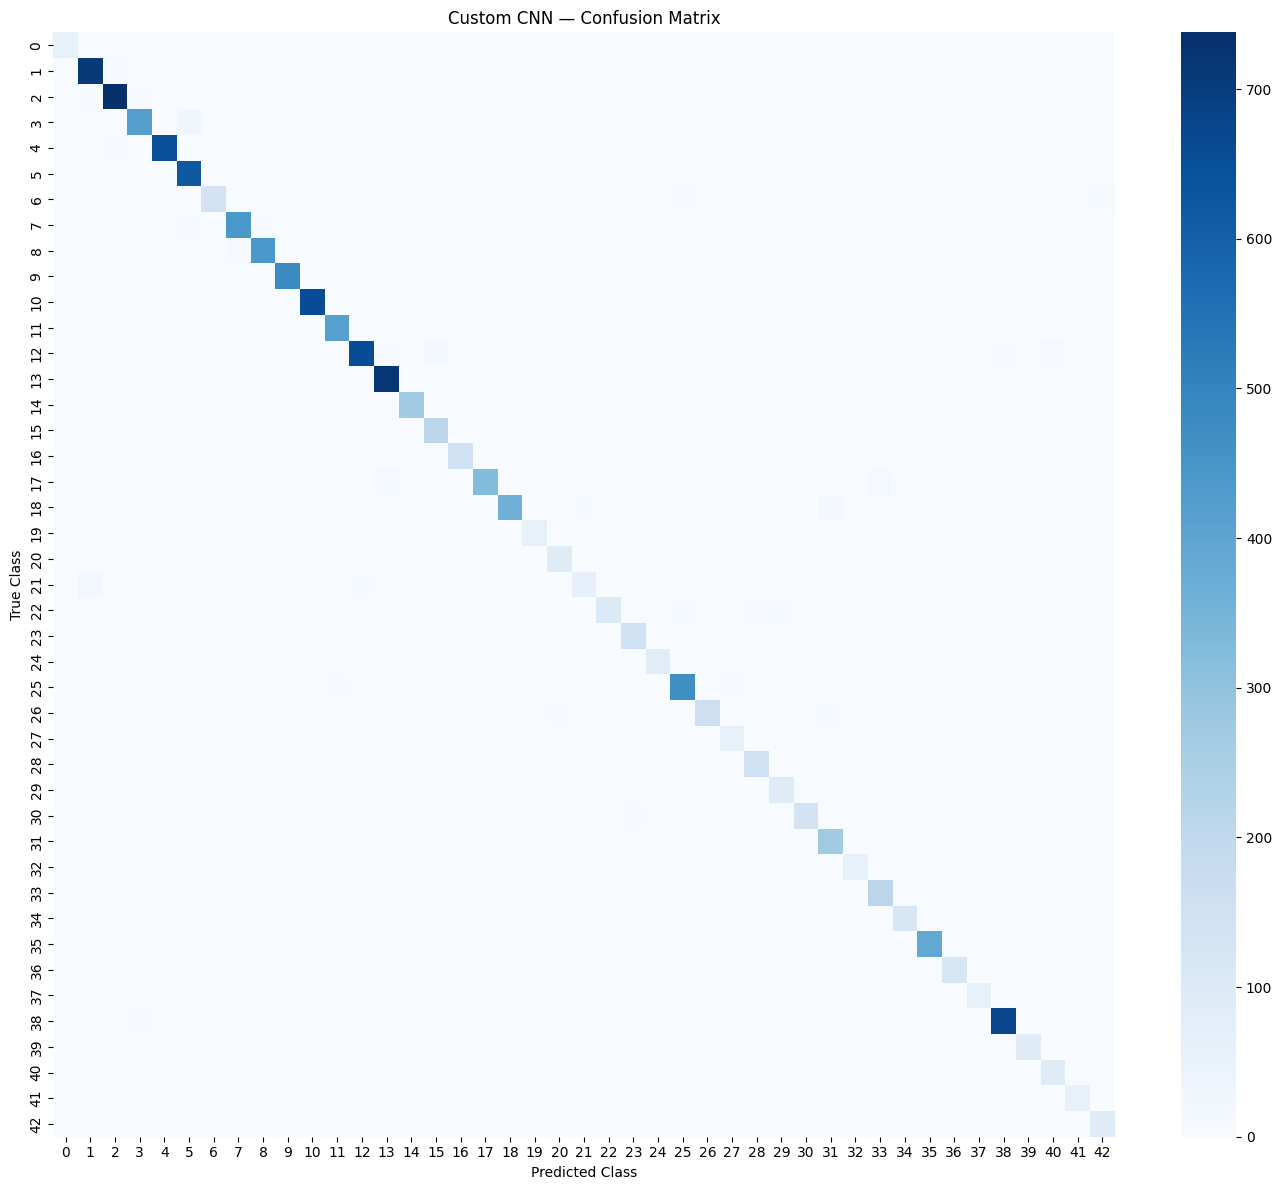


MobileNetV2 — Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        60
           1       0.98      0.99      0.99       720
           2       0.96      0.99      0.98       750
           3       0.99      0.96      0.98       450
           4       1.00      0.98      0.99       660
           5       0.96      0.98      0.97       630
           6       0.99      0.97      0.98       150
           7       0.95      0.97      0.96       450
           8       0.96      0.96      0.96       450
           9       0.98      1.00      0.99       480
          10       0.99      0.99      0.99       660
          11       0.96      0.98      0.97       420
          12       0.96      0.99      0.97       690
          13       0.97      0.99      0.98       720
          14       0.99      1.00      0.99       270
          15       0.98      1.00      0.99       210
          16       0.99      1.00      1.00

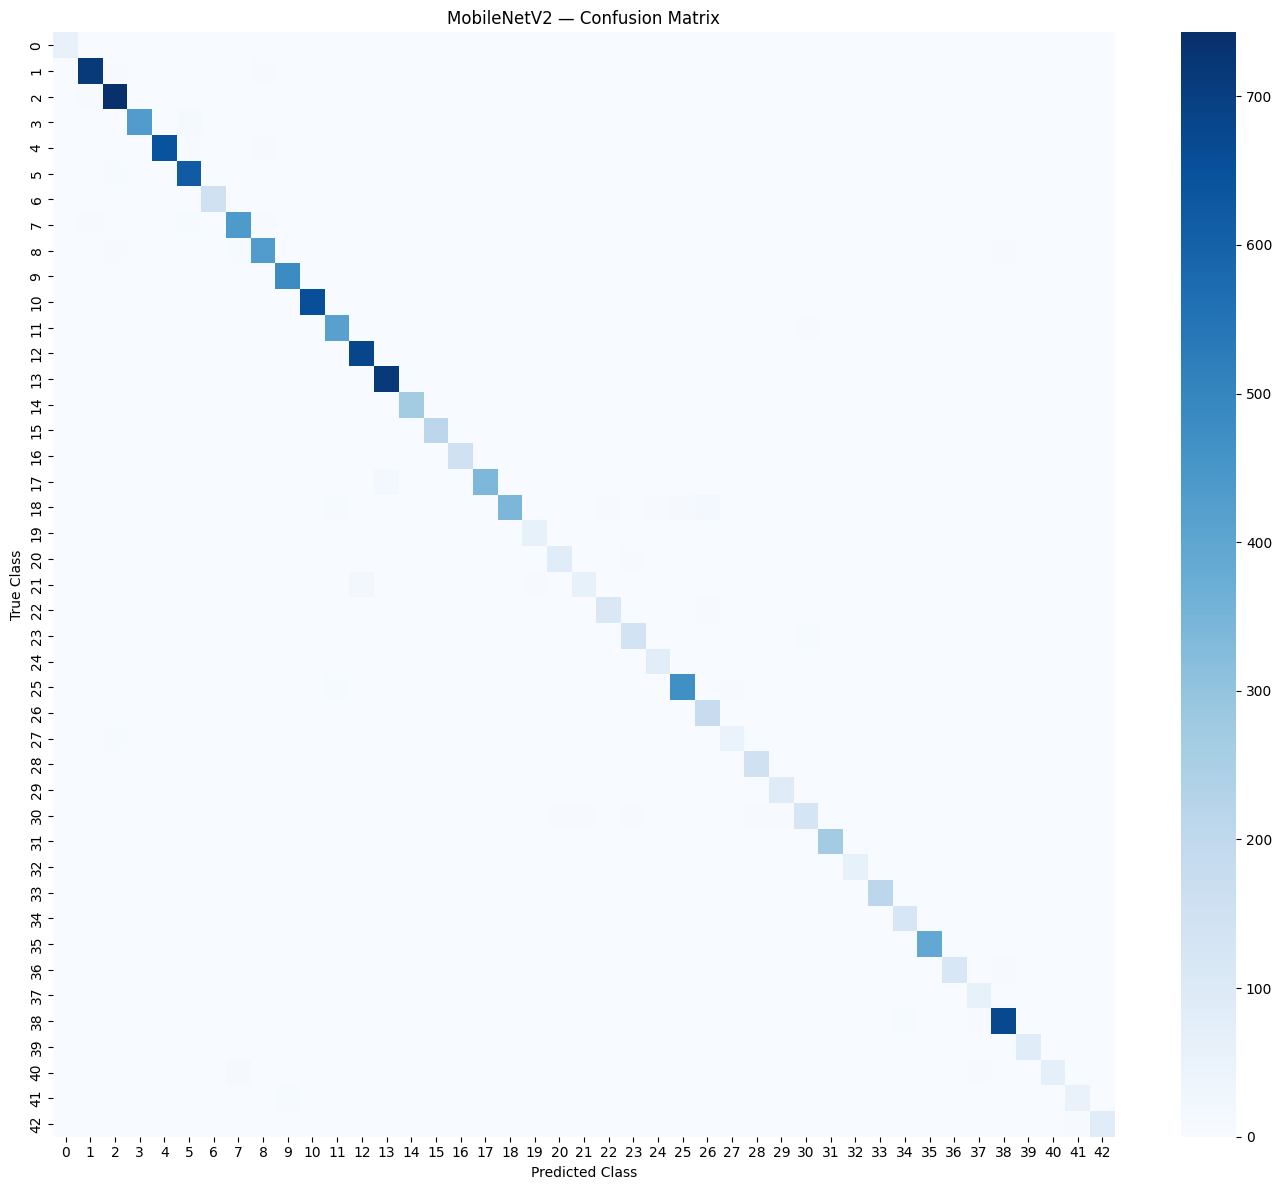

In [21]:
def evaluate_model(model, X, y_true, name):
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    print(f'\n{name} — Classification Report:')
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=range(43), yticklabels=range(43))
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.tight_layout()
    plt.show()

evaluate_model(cnn_model, X_test,     y_test, 'Custom CNN')
evaluate_model(mob_model, X_test_mob, y_test, 'MobileNetV2')

## Visualize Predictions

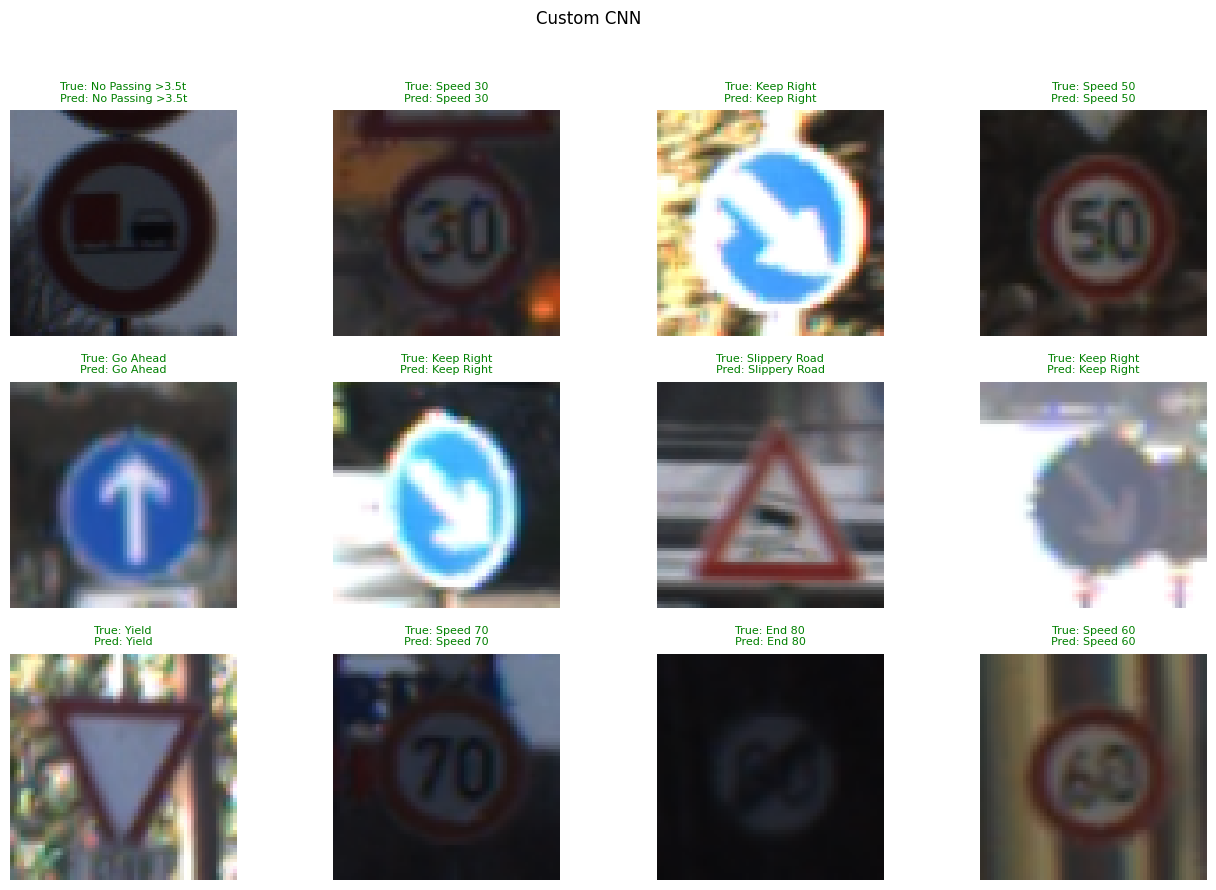

2026-03-03 01:02:58.316232: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 01:02:58.452080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


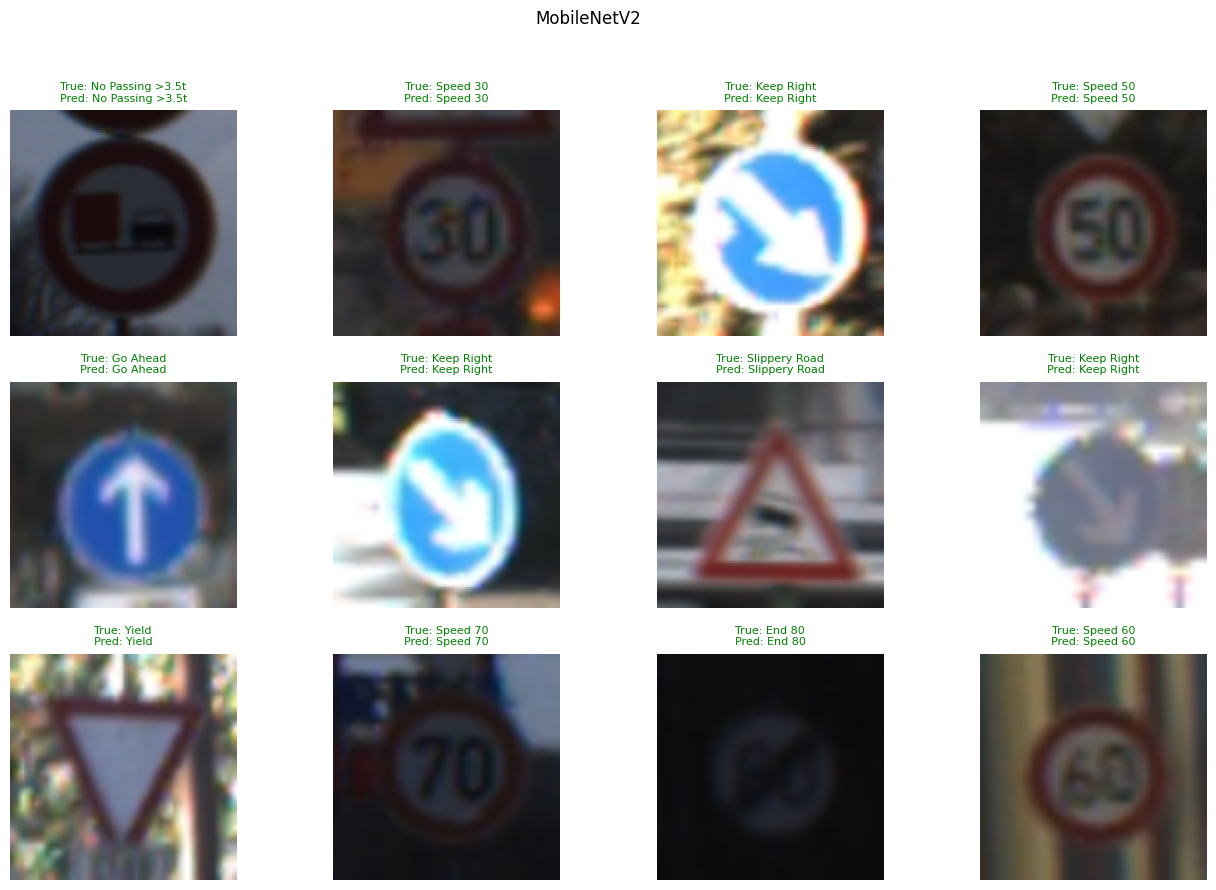

In [22]:
CLASS_NAMES = ['Speed 20','Speed 30','Speed 50','Speed 60','Speed 70',
               'Speed 80','End 80','Speed 100','Speed 120','No Passing',
               'No Passing >3.5t','Right of Way','Priority Road','Yield','Stop',
               'No Vehicles','No Trucks','No Entry','Danger','Left Curve',
               'Right Curve','Double Curve','Bumpy Road','Slippery Road','Road Narrows',
               'Road Work','Traffic Signals','Pedestrians','Children','Cyclists',
               'Ice/Snow','Wild Animals','End Restrictions','Turn Right','Turn Left',
               'Go Ahead','Go Right/Ahead','Go Left/Ahead','Keep Right','Keep Left',
               'Roundabout','End No Passing','End No Passing >3.5t']

def show_predictions(model, X, y_true, model_name, num_images=12):
    y_pred = np.argmax(model.predict(X[:num_images], verbose=0), axis=1)
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.flatten()
    for i in range(num_images):
        axes[i].imshow(X[i])
        color = 'green' if y_true[i] == y_pred[i] else 'red'
        axes[i].set_title(f'True: {CLASS_NAMES[y_true[i]]}\nPred: {CLASS_NAMES[y_pred[i]]}',
                          fontsize=8, color=color)
        axes[i].axis('off')
    plt.suptitle(f'{model_name}', fontsize=12)

    plt.show()

idx = np.random.permutation(len(X_test))[:12]
show_predictions(cnn_model, X_test[idx],     y_test[idx], 'Custom CNN')
show_predictions(mob_model, X_test_mob[idx], y_test[idx], 'MobileNetV2')

## Save Models

In [23]:
cnn_model.save('/kaggle/working/traffic_cnn.keras')
mob_model.save('/kaggle/working/traffic_mobilenet.keras')
print('Models saved to /kaggle/working/')
print('Go to the Output tab on the right to download them')
from tensorflow import keras
model = keras.models.load_model('/kaggle/working/traffic_cnn.keras')

Models saved to /kaggle/working/
Go to the Output tab on the right to download them
